<a href="https://colab.research.google.com/github/parika8ec-hub/Assignment10/blob/main/Assignment10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




In [217]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

!pip install transformers datasets torch -q
#Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

In [218]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest

# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')
'''
Note: Comment google drive link because it asks for authorization.
'''

# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive

#Load dataset
review_data = pd.read_csv('sample_data/amazon_alexa.tsv', sep='\t')

#display few rows of dataset
print('Few Rows of Amazon Alexa Customer Review Dataset:')
print(review_data.head())

Few Rows of Amazon Alexa Customer Review Dataset:
   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  


In [219]:
#Information of Dataset
print('Information of Dataset:')
print(review_data.info())

Information of Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB
None


In [220]:
#Check missing values
print('Missing Values:')
print(review_data.isnull().sum())

Missing Values:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [221]:
#Fill missing values
# Missing values
review_data['verified_reviews'] =review_data['verified_reviews'].fillna('Not mentioned')

#Check missing values after filling
print('Missing Values:\n',review_data.isnull().sum())

'''
Note: Feature Scaling is not needed because our model is Random Forest.
'''

Missing Values:
 rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64


'\nNote: Feature Scaling is not needed because our model is Random Forest.\n'

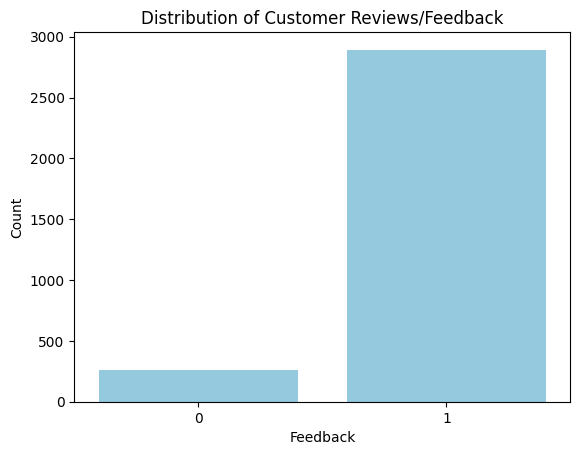

In [222]:
# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

# Create countplot for distribution of feedback
sns.countplot(x='feedback', data=review_data,color='skyblue')
# Add title and label of axis
plt.title('Distribution of Customer Reviews/Feedback')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()#display plot

/tmp/ipykernel_3807/2676970344.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='variation', y='rating', data=review_data, palette = 'pastel')


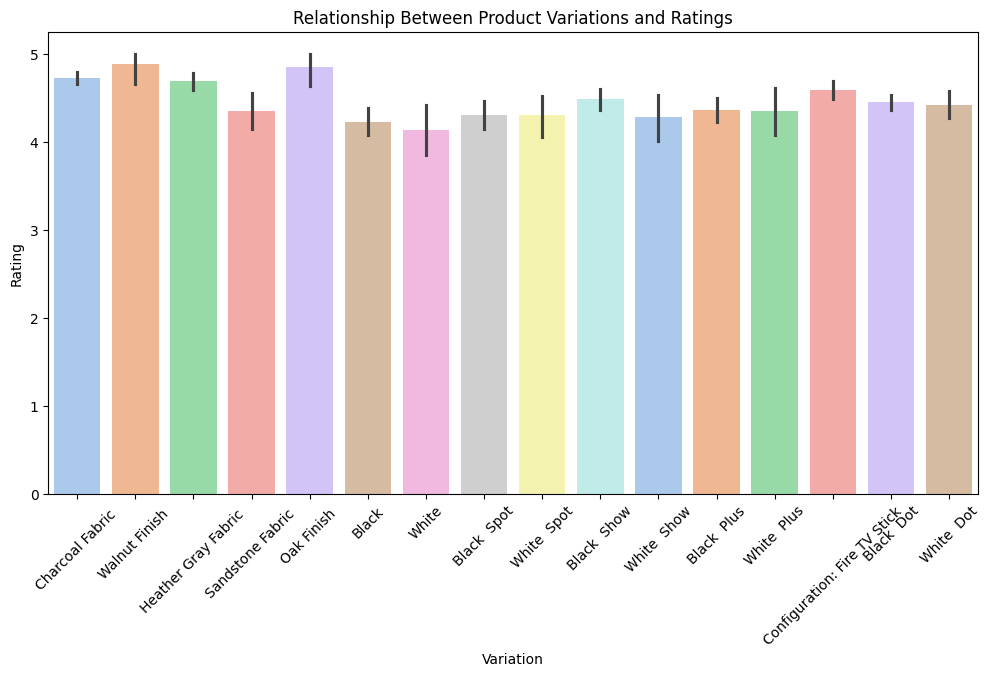

In [223]:
# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

plt.figure(figsize=(12,6))#set plot figure size
# Create bar plot for relationship between variation and rating of product
sns.barplot(x='variation', y='rating', data=review_data, palette = 'pastel')
# Add title and label of axis
plt.title('Relationship Between Product Variations and Ratings')
plt.xlabel('Variation')
plt.ylabel('Rating')
#Add xticks value rotation
plt.xticks(rotation=45)
plt.show()#display plot

In [224]:
# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

# Drop irrelevant columns
review_data = review_data.drop(columns=['date', 'rating'])

# Check remaining columns
print('Remaining columns:',review_data.columns)

Remaining columns: Index(['variation', 'verified_reviews', 'feedback'], dtype='object')


In [225]:
# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

# One-hot encode the 'variation' column
review_data = pd.get_dummies(review_data, columns=['variation'])

#Check updated dataset
print('Updated Dataset:')
print(review_data.head())

Updated Dataset:
                                    verified_reviews  feedback  \
0                                      Love my Echo!         1   
1                                          Loved it!         1   
2  Sometimes while playing a game, you can answer...         1   
3  I have had a lot of fun with this thing. My 4 ...         1   
4                                              Music         1   

   variation_Black  variation_Black  Dot  variation_Black  Plus  \
0            False                 False                  False   
1            False                 False                  False   
2            False                 False                  False   
3            False                 False                  False   
4            False                 False                  False   

   variation_Black  Show  variation_Black  Spot  variation_Charcoal Fabric   \
0                  False                  False                        True   
1                  False 

In [226]:
# Tokenization (Count Vectorizer) as Bag of Words
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the review text
X_text = vectorizer.fit_transform(review_data['verified_reviews'])

# Check shape of the resulting matrix
print(X_text.shape)

(3150, 4044)


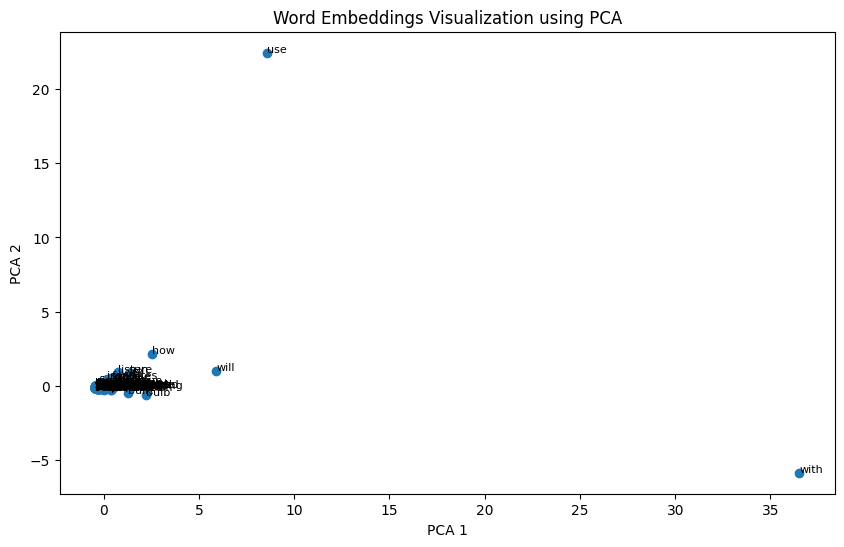

In [227]:
#Visualize word embeddings to explore semantic relationships between words (using t-SNE or PCA for dimensionality reduction)
# Get feature matrix (words)
X_words = X_text_df.sample(200, axis=1).T   # take 200 words to reduce clutter

# Apply and fit PCA to reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(X_words)
plt.figure(figsize=(10,6))#set plot size
plt.scatter(reduced[:,0], reduced[:,1])#create scatter plot

# Add word labels
words = X_words.index
for i, word in enumerate(words):
    plt.text(reduced[i,0], reduced[i,1], word, fontsize=8)
#Add title and label of axis
plt.title("Word Embeddings Visualization using PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()#display plot

In [228]:
# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

# Convert the tokenized review text (sparse matrix) into a readable DataFrame where each column represents a unique word from the vocabulary
X_text_df = pd.DataFrame(X_text.toarray(), columns=vectorizer.get_feature_names_out())

#Remove the original verified_reviews text column and concatenate it with the CountVectorizer output X_text_df
# to create a final dataset containing only numerical features for modeling
df_combined = pd.concat([review_data.drop(columns=['verified_reviews']), X_text_df], axis=1)

#Display concated dataframe
print('Concated Dataframe:')
print(df_combined.head())

#remove duplicate columns and keep first one
df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

Concated Dataframe:
   feedback  variation_Black  variation_Black  Dot  variation_Black  Plus  \
0         1            False                 False                  False   
1         1            False                 False                  False   
2         1            False                 False                  False   
3         1            False                 False                  False   
4         1            False                 False                  False   

   variation_Black  Show  variation_Black  Spot  variation_Charcoal Fabric   \
0                  False                  False                        True   
1                  False                  False                        True   
2                  False                  False                       False   
3                  False                  False                        True   
4                  False                  False                        True   

   variation_Configuration: Fire TV Stick 

In [229]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

# Select Features and Target variable of combined final dataset
X = df_combined.drop(columns=['feedback'])#feature values after droping feedback column
y = df_combined['feedback']#target variable as feedback

In [230]:
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection
#Split data into 80% training set and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)

In [231]:
# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Train model on tarining data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [232]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics

# Predict on test data
y_pred = rf_model.predict(X_test)

#Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[ 20  38]
 [  5 567]]


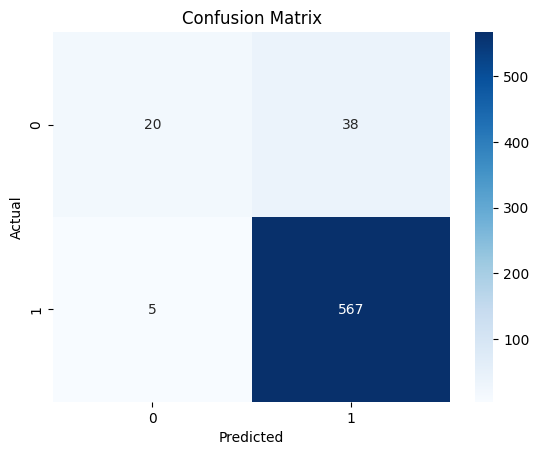

In [233]:
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function
#Create heatmap for confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#Add title and label of axis
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

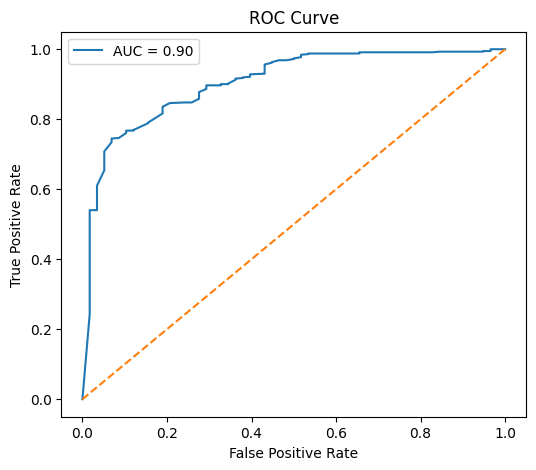

In [234]:
# Get probability scores whic is important for ROC
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,5))#set plot size
#Create line plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
#Add title and label of axis
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()#add legend

plt.show()#display plot

In [235]:
# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.34      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.87      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



In [236]:
# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

# Get feature importance values
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

#Display result of feature_importance_df
print('Feature Importance:')
print(feature_importance_df.head())

Feature Importance:
                 feature  importance
0        variation_Black    0.002531
1   variation_Black  Dot    0.003313
2  variation_Black  Plus    0.002007
3  variation_Black  Show    0.001946
4  variation_Black  Spot    0.003531


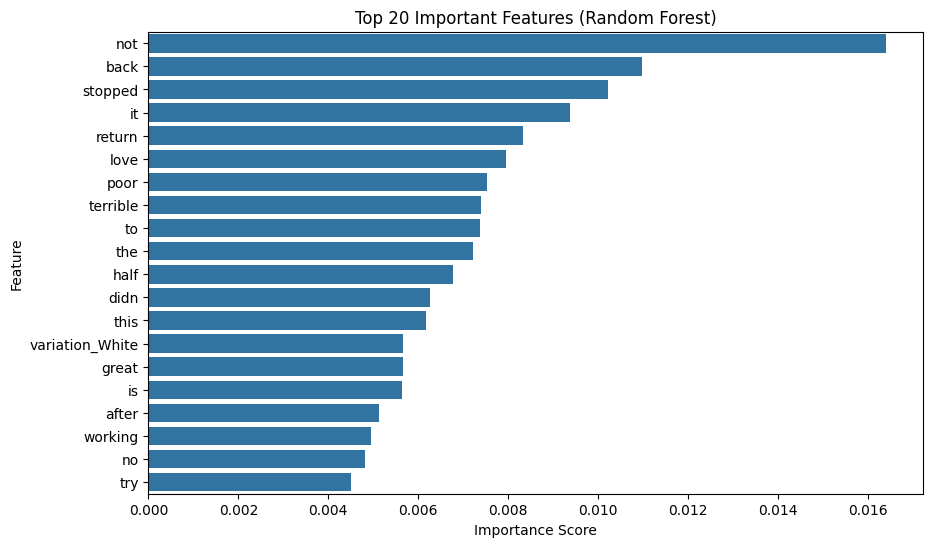

In [237]:
# Sort top features
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10,6))#set plot size
#create bar plot
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
#Add title and label of axis
plt.title("Top 20 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
#Display plot
plt.show()

# Feature Importance Interpretation:

The feature importance chart shows which words and features most influenced the model's sentiment predictions.

1) Words like “not”, “poor”, “terrible”, “no” are highly important. These are strong indicators of negative sentiment.

2) Words like “love”, “great”, “working” also appear. These indicate positive sentiment

3) Some stopwords like “to”, “the”, “is” appear as important features.This happens because CountVectorizer was used without removing all stopwords or without TF-IDF weighting.

The model is learning sentiment patterns correctly (positive vs negative words)

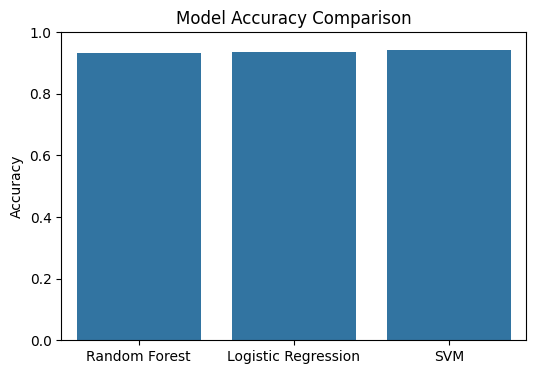

In [238]:
#Model comparison chart
models = ['Random Forest', 'Logistic Regression', 'SVM']#model name list
scores = [rf_model.score(X_test, y_test),
          log_best.score(X_test, y_test),
          svm_best.score(X_test, y_test)]#model score list

plt.figure(figsize=(6,4))#set plot size
sns.barplot(x=models, y=scores)#create bar plot
#Add title and label of axis with limit of y axis
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
#Display plot
plt.show()

# Model Comparison Interpretation:

SVM performs slightly better, likely because it handles high-dimensional text data very well

Logistic Regression is very close to SVM, showing strong linear separability in the dataset

Random Forest also performs well, but slightly lower due to sparse text features not being ideal for tree-based models

In [258]:
# TODO: Make predictions on new data using Random Forest
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

def predict_sentiment(review_text,variation="Black"):
    # Convert input text into vector format using trained vectorizer
    review_vector = vectorizer.transform([review_text])

    # Convert to DataFrame to match training format
    text_df = pd.DataFrame(review_vector.toarray(),columns=vectorizer.get_feature_names_out())

    #Get variation columns from training data
    variation_columns = [col for col in X.columns if col.startswith("variation_")]

    # Create empty variation dummy columns same as training
    variation_df = pd.DataFrame(0, index=[0], columns=variation_columns)

    # Activate correct variation column
    col_name = f"variation_{variation}"
    if col_name in variation_df.columns:
        variation_df[col_name] = 1

    #Align both parts
    text_df = text_df.reindex(columns=[col for col in X.columns if col not in variation_columns and col != "feedback"], fill_value=0)

    # Combine features exactly like training
    final_input = pd.concat([variation_df, text_df], axis=1)

    # Make prediction using random forest
    prediction = rf_model.predict(final_input)

    # Convert numeric output to readable label
    if prediction[0] == 1:
        return "Positive"
    else:
        return "Negative"

# Example usage of your prediction function:
new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")

The sentiment of the new review is: Positive


# Text Classification Using Traditional Model as SVM Classifier and Logistic Regression with Grid Search

In [240]:
# Text Classification Using Traditional Model

#Logistic Regression with Grid Search

# Initialize Logistic Regression model with increased iterations for convergence
log_model = LogisticRegression(max_iter=1000)

# Define hyperparameter grid for tuning
log_params = {
    'C': [0.1, 1, 10],          # Regularization strength
    'penalty': ['l2'],         # Type of regularization
    'solver': ['liblinear']    # Optimization algorithm
}
# Apply GridSearchCV for hyperparameter tuning with 5-fold cross-validation
log_grid = GridSearchCV(log_model, log_params, cv=5, scoring='accuracy')

# Train model on training data and search for best parameters
log_grid.fit(X_train, y_train)

# Extract the best-performing Logistic Regression model
log_best = log_grid.best_estimator_

#Predict value on test data
y_pred_log = log_best.predict(X_test)
#Compute accuracy score and cl;assification report
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

#Apply SVM with GridSearcch
# Initialize Support Vector Machine (SVM) model
svm_model = SVC()

# Define hyperparameter grid for tuning SVM
svm_params = {
    'C': [0.1, 1, 10],            # Regularization parameter (controls margin vs error tradeoff)
    'kernel': ['linear', 'rbf'],  # Type of kernel function
    'gamma': ['scale', 'auto']    # Kernel coefficient for 'rbf'
}

# Apply GridSearchCV for hyperparameter tuning with 5-fold cross-validation
svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy')

# Train SVM model and search for best hyperparameters
svm_grid.fit(X_train, y_train)

# Extract the best-performing SVM model
svm_best = svm_grid.best_estimator_

#predict value on test set
y_pred_svm = svm_best.predict(X_test)
#Compute accuracy score and cl;assification report
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

#Compare models
print("Best Logistic Regression Params:", log_grid.best_params_)
print("Best SVM Params:", svm_grid.best_params_)

Logistic Regression Accuracy: 0.9349206349206349
              precision    recall  f1-score   support

           0       0.74      0.45      0.56        58
           1       0.95      0.98      0.96       572

    accuracy                           0.93       630
   macro avg       0.84      0.72      0.76       630
weighted avg       0.93      0.93      0.93       630

SVM Accuracy: 0.9428571428571428
              precision    recall  f1-score   support

           0       0.92      0.41      0.57        58
           1       0.94      1.00      0.97       572

    accuracy                           0.94       630
   macro avg       0.93      0.71      0.77       630
weighted avg       0.94      0.94      0.93       630

Best Logistic Regression Params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [260]:
# TODO: Make predictions on new data using SVM Model as Best Model for this analysis
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

def predict_sentiment1(review_text,variation="Black"):
    # Convert input text into vector format using trained vectorizer
    review_vector = vectorizer.transform([review_text])

    # Convert to DataFrame to match training format
    text_df = pd.DataFrame(review_vector.toarray(),columns=vectorizer.get_feature_names_out())

    #Get variation columns from training data
    variation_columns = [col for col in X.columns if col.startswith("variation_")]

    # Create empty variation dummy columns same as training
    variation_df = pd.DataFrame(0, index=[0], columns=variation_columns)

    # Activate correct variation column
    col_name = f"variation_{variation}"
    if col_name in variation_df.columns:
        variation_df[col_name] = 1

    #Align both parts
    text_df = text_df.reindex(columns=[col for col in X.columns if col not in variation_columns and col != "feedback"], fill_value=0)

    # Combine features exactly like training
    final_input = pd.concat([variation_df, text_df], axis=1)

    # Make prediction using random forest
    prediction = svm_best.predict(final_input)

    # Convert numeric output to readable label
    if prediction[0] == 1:
        return "Positive"
    else:
        return "Negative"

# Example usage of your prediction function:
new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment1(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")

The sentiment of the new review is: Positive


#Sentiment Analysis Using a Large Language Model

In [243]:
#Sentiment Analysis Using a Large Language Model
'''
Note: This code is taking too long to run.So, I will try same code in another colab and submit it.

'''

#Prepare dataset
# Select relevant columns
df = review_data[['verified_reviews', 'feedback']].dropna()

# Rename for Hugging Face format
df.columns = ['text', 'label']

# Train-test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].astype(str),
    df['label'],
    test_size=0.2,
    random_state=42
)

#Load BERT Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

#Tokenization function
def tokenize_function(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128
    )

#Convert to Hugging Face Dataset
train_encodings = tokenize_function(train_texts)
test_encodings = tokenize_function(test_texts)

train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels.tolist()
})

#Load Pre-trained BERT Model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

#Training Setup (Fine-tuning)
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    num_train_epochs=3
)

# Trainer API (Fine-tuning BERT)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)
#trainer.evaluate()
trainer.train()

#Model Evaluation
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, y_pred))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Step,Training Loss


KeyboardInterrupt: 

In [244]:
# Task 1: Import Libraries and Dataset

# Hint: You need to import libraries like pandas, numpy, matplotlib, seaborn, etc.
# Don't forget to mount Google Drive and load the CSV file using pandas.
# Use `pd.read_csv()` to load the data into a pandas DataFrame.
'''
Note: Not use google drive link because it asks for authorization.
'''

# TODO: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [245]:
# TODO: Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

# TODO: Load the dataset into a DataFrame and preview the first few rows.
# Load dataset (NO Google Drive used)
review_data1 = pd.read_csv('sample_data/amazon_alexa.tsv', sep='\t')

# Preview first few rows
print("First 5 rows of Dataset:")
print(review_data1.head())

First 5 rows of Dataset:
   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  


In [246]:
#Check missing values
print('Missing Values:')
print(review_data1.isnull().sum())

#Fill missing values
# Missing values
review_data1['verified_reviews'] =review_data1['verified_reviews'].fillna('Not mentioned')

Missing Values:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


/tmp/ipykernel_3807/3578785373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=review_data1['feedback'].map({0: 'Negative', 1: 'Positive'}), palette='pastel')


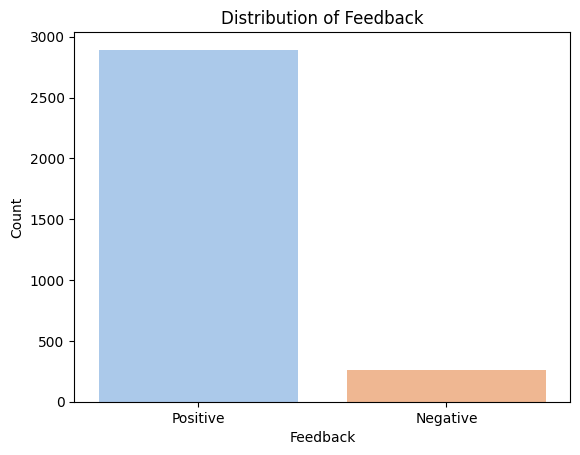

In [247]:
# TODO: Visualize the distribution of feedback (positive/negative)
# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
#Create feedback distribution count plot
sns.countplot(x=review_data1['feedback'].map({0: 'Negative', 1: 'Positive'}), palette='pastel')
#Add title and label of axis
plt.title('Distribution of Feedback')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()#display plot

/tmp/ipykernel_3807/92406411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='variation', y='feedback', data=review_data1,palette='muted')


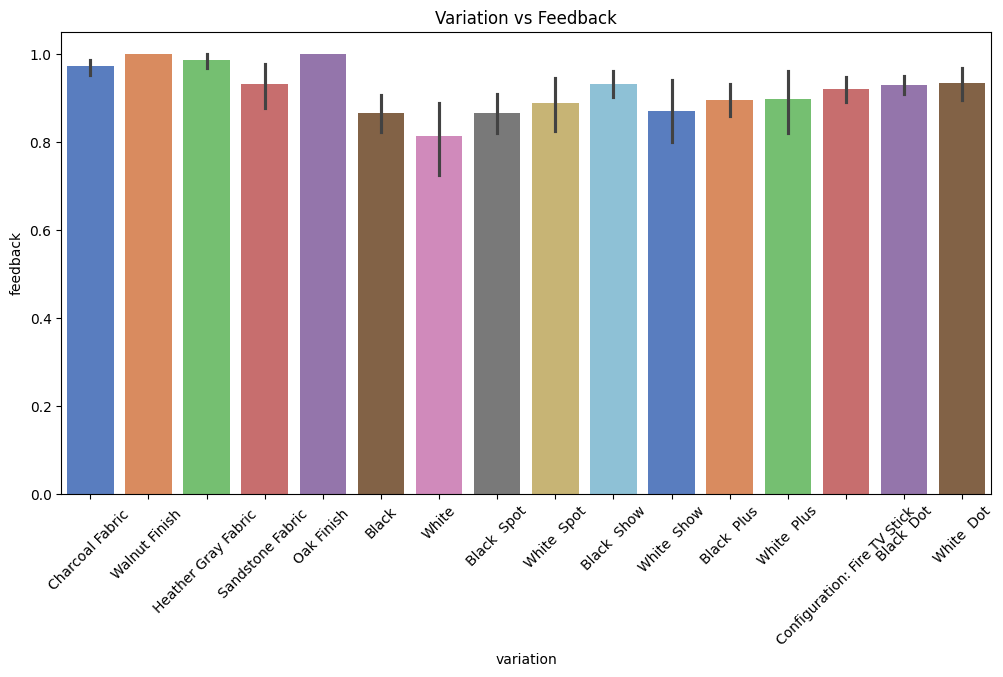

In [248]:
# TODO: Visualize the relationship between product variation and feedback
#Create barplot for relationship between variation and feedback
plt.figure(figsize=(12,6))#set figure size
#Create bar plot
sns.barplot(x='variation', y='feedback', data=review_data1,palette='muted')
#Add title and xticks
plt.title('Variation vs Feedback')
plt.xticks(rotation=45)
plt.show()#display plot

In [249]:
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.
# TODO: Drop irrelevant columns ('date', 'rating')
review_data1 = review_data1.drop(columns=['date', 'rating'])#drop columns as date and rating
print("Remaining columns:", review_data1.columns)#display result

Remaining columns: Index(['variation', 'verified_reviews', 'feedback'], dtype='object')


In [250]:
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
variation_encoded = pd.get_dummies(review_data1['variation'], prefix='variation')
print('Encoded data:')
print(variation_encoded.head())

Encoded data:
   variation_Black  variation_Black  Dot  variation_Black  Plus  \
0            False                 False                  False   
1            False                 False                  False   
2            False                 False                  False   
3            False                 False                  False   
4            False                 False                  False   

   variation_Black  Show  variation_Black  Spot  variation_Charcoal Fabric   \
0                  False                  False                        True   
1                  False                  False                        True   
2                  False                  False                       False   
3                  False                  False                        True   
4                  False                  False                        True   

   variation_Configuration: Fire TV Stick  variation_Heather Gray Fabric   \
0                              

In [251]:
# TODO: Tokenize the 'verified_reviews' column using CountVectorizer
# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.

#Initialize CountVectorizer
vectorizer1 = CountVectorizer()
#Fit and Transform review text
X_text1 = vectorizer1.fit_transform(review_data1['verified_reviews'])

# Convert to DataFrame
X_text_df1 = pd.DataFrame(X_text1.toarray(),columns=vectorizer1.get_feature_names_out())

# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.
#and also after transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# Combine with dataset
df_combined1 = pd.concat([review_data1.drop(columns=['verified_reviews', 'variation']).reset_index(drop=True),
                          variation_encoded.reset_index(drop=True),X_text_df1.reset_index(drop=True)],axis=1)

'''
Note:
The variation column is dropped because it is categorical and converted into numerical form using one-hot encoding.
The verified_reviews column is dropped because it is raw text data and transformed into numerical features using CountVectorizer.
Both transformations are necessary to make the dataset suitable for machine learning models such as Random Forest.
'''
# Remove duplicates if any
df_combined1 = df_combined1.loc[:, ~df_combined1.columns.duplicated()]

print('Combined Dataset:')
print(df_combined1.head())

Combined Dataset:
   feedback  variation_Black  variation_Black  Dot  variation_Black  Plus  \
0         1            False                 False                  False   
1         1            False                 False                  False   
2         1            False                 False                  False   
3         1            False                 False                  False   
4         1            False                 False                  False   

   variation_Black  Show  variation_Black  Spot  variation_Charcoal Fabric   \
0                  False                  False                        True   
1                  False                  False                        True   
2                  False                  False                       False   
3                  False                  False                        True   
4                  False                  False                        True   

   variation_Configuration: Fire TV Stick  v

In [252]:
# TODO: Split the data into training and testing sets
# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

#Select Target and Features
X1 = df_combined1.drop(columns=['feedback'])#features columns after droping feedback column
y1 = df_combined1['feedback']#target variable as feedback column

#Split data into 80% training and 20% testing
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1,test_size=0.2,random_state=42)

In [253]:
# TODO: Define and train a Random Forest Classifier
# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

#Initialize Random Forest Classifier with n_estimators=100 as 100 different decision trees
rf_model1 = RandomForestClassifier(n_estimators=100, random_state=42)
#Fit model on train set
rf_model1.fit(X_train1, y_train1)

RandomForestClassifier(random_state=42)

In [254]:
# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report
# Hint: Use the `predict()` method to generate predictions for the test data.
y_pred1 = rf_model1.predict(X_test1)#predict value on test set

# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
# Find Confusion matrix
cm1 = confusion_matrix(y_test1, y_pred1)
print("Confusion Matrix:")
print(cm1)

Confusion Matrix:
[[ 20  38]
 [  5 567]]


# Confusion Matrix Interpretation on Classes

**Class 0 (Negative reviews):**

20 correctly predicted (True Negatives)

38 incorrectly predicted as Positive (False Positives)

**Class 1 (Positive reviews):**

567 correctly predicted (True Positives)

5 incorrectly predicted as Negative (False Negatives)

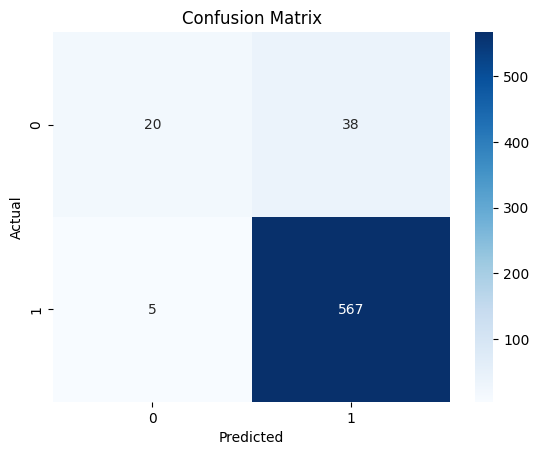

In [255]:
# Create Heatmap for Confusion Matrix
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
#Add title and label of axis
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()#display plot

# Interpretation of Confusion Matrix



*   True Negatives (TN = 20) shows correctly predicted negative reviews
*   False Positives (FP = 38) shows negative reviews wrongly predicted as positive
*   False Negatives (FN = 5) shows positive reviews wrongly predicted as negative
*   True Positives (TP = 567) shows correctly predicted positive reviews

In [256]:
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.
# Display Classification report
print("Classification Report:")
print(classification_report(y_test1, y_pred1))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.34      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.87      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



# Classification Report Insights

**Class 0 (Negative):**

Precision: 0.80 shows when it predicts negative, it's fairly reliable

Recall: 0.34 shows it misses many actual negative reviews

F1-score: 0.48 shows poor balance due to low recall

**Class 1 (Positive):**

Precision: 0.94 shows very reliable

Recall: 0.99 shows almost all positive reviews are correctly identified

F1-score: 0.96 shows excellent performance

In [257]:
# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
train_acc = rf_model.score(X_train, y_train)#calculate accuracy of training data
test_acc = rf_model.score(X_test, y_test)#calculate accuracy of test data
print("Training Accuracy:", round(train_acc,2))
print("Testing Accuracy:", round(test_acc,2))

Training Accuracy: 1.0
Testing Accuracy: 0.93


# Compare training and testing accuracy and discuss model performance:

Training Accuracy = 1.0 means the model has perfectly learned the training data.It correctly classifies all training samples
suggests the model is very flexible as Random Forest with many trees.

Testing Accuracy = 0.93 shows the model performs very well on unseen data. The 93% accuracy means strong generalization and only a small number of misclassifications.


# Compare the results and discuss if the model is overfitting or underfitting:

The Random Forest model achieved perfect accuracy on the training set and 93% accuracy on the test set, indicating strong learning capability with slight overfitting. The classification report shows that the model performs exceptionally well in identifying positive reviews but struggles with negative reviews due to class imbalance. The low recall for class 0 suggests that many negative reviews are misclassified as positive. Overall, the model generalizes well but could be improved by handling class imbalance or tuning hyperparameters.